In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!wget https://bitbucket.org/ishaanjav/code-and-deploy-custom-tensorflow-lite-model/raw/a4febbfee178324b2083e322cdead7465d6fdf95/fruits.zip

--2026-02-11 11:38:38--  https://bitbucket.org/ishaanjav/code-and-deploy-custom-tensorflow-lite-model/raw/a4febbfee178324b2083e322cdead7465d6fdf95/fruits.zip
Resolving bitbucket.org (bitbucket.org)... 104.192.142.25, 104.192.142.24, 104.192.142.26, ...
Connecting to bitbucket.org (bitbucket.org)|104.192.142.25|:443... connected.
HTTP request sent, awaiting response... 404 Not Found
2026-02-11 11:38:39 ERROR 404: Not Found.



In [3]:
!unzip fruits.zip

Archive:  fruits.zip
   creating: fruits/
   creating: fruits/test/
  inflating: fruits/test/.DS_Store   
   creating: fruits/test/apple/
  inflating: fruits/test/apple/Screen Shot 2018-06-08 at 5.25.54 PM.png  
  inflating: fruits/test/apple/Screen Shot 2018-06-08 at 5.26.05 PM.png  
  inflating: fruits/test/apple/Screen Shot 2018-06-08 at 5.26.13 PM.png  
  inflating: fruits/test/apple/Screen Shot 2018-06-08 at 5.26.19 PM.png  
  inflating: fruits/test/apple/Screen Shot 2018-06-08 at 5.26.24 PM.png  
  inflating: fruits/test/apple/Screen Shot 2018-06-08 at 5.26.29 PM.png  
  inflating: fruits/test/apple/Screen Shot 2018-06-08 at 5.26.36 PM.png  
  inflating: fruits/test/apple/Screen Shot 2018-06-08 at 5.26.41 PM.png  
  inflating: fruits/test/apple/Screen Shot 2018-06-08 at 5.26.47 PM.png  
  inflating: fruits/test/apple/Screen Shot 2018-06-08 at 5.26.52 PM.png  
  inflating: fruits/test/apple/Screen Shot 2018-06-08 at 5.26.58 PM.png  
  inflating: fruits/test/apple/Screen Shot 2018-

In [4]:
import tensorflow as tf
import matplotlib.pyplot as plt

In [5]:
tf.__version__

'2.19.0'

In [6]:
img_height, img_width = 32, 32
batch_size = 20

train_ds = tf.keras.utils.image_dataset_from_directory(
    "fruits/train",
    image_size = (img_height, img_width),
    batch_size = batch_size
)
val_ds = tf.keras.utils.image_dataset_from_directory(
    "fruits/validation",
    image_size = (img_height, img_width),
    batch_size = batch_size
)
test_ds = tf.keras.utils.image_dataset_from_directory(
    "fruits/test",
    image_size = (img_height, img_width),
    batch_size = batch_size
)

Found 460 files belonging to 3 classes.
Found 66 files belonging to 3 classes.
Found 130 files belonging to 3 classes.


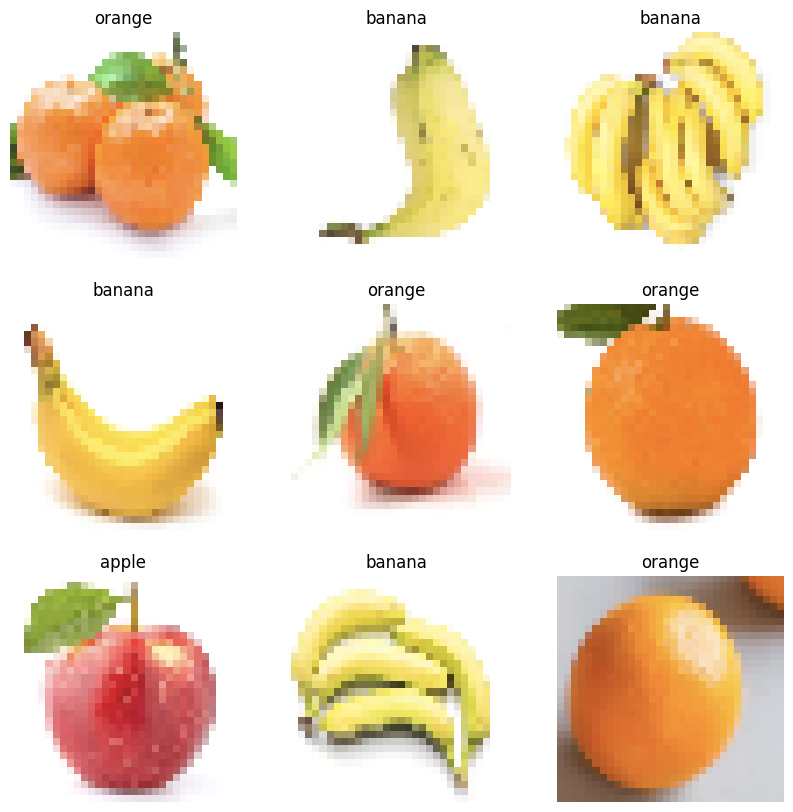

In [7]:
class_names = ["apple", "banana", "orange"]
plt.figure(figsize=(10,10))

for images, labels in train_ds.take(1):
  for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[labels[i]])
    plt.axis("off")

In [8]:
model = tf.keras.Sequential(
    [
     tf.keras.layers.Rescaling(1./255),
     tf.keras.layers.Conv2D(32, 3, activation="relu"),
     tf.keras.layers.MaxPooling2D(),
     tf.keras.layers.Conv2D(64, 3, activation="relu"),
     tf.keras.layers.MaxPooling2D(),
     tf.keras.layers.Conv2D(128, 3, activation="relu"),
     tf.keras.layers.MaxPooling2D(),
     tf.keras.layers.Flatten(),
     tf.keras.layers.Dense(128, activation="softmax"),
     tf.keras.layers.Dense(3)
    ]
)

In [9]:
model.compile(
    optimizer="rmsprop",
    loss=tf.losses.SparseCategoricalCrossentropy(from_logits = True),
    metrics=['accuracy']
)

In [10]:
model.fit(
    train_ds,
    validation_data = val_ds,
    epochs = 20
)

Epoch 1/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 7s 131ms/step - accuracy: 0.3319 - loss: 1.0991 - val_accuracy: 0.6364 - val_loss: 1.0962
Epoch 2/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 65ms/step - accuracy: 0.4143 - loss: 1.0921 - val_accuracy: 0.3485 - val_loss: 1.0563
Epoch 3/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 89ms/step - accuracy: 0.4822 - loss: 1.0436 - val_accuracy: 0.5606 - val_loss: 1.0201
Epoch 4/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 109ms/step - accuracy: 0.6033 - loss: 0.9965 - val_accuracy: 0.6515 - val_loss: 0.9531
Epoch 5/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 67ms/step - accuracy: 0.6366 - loss: 0.9604 - val_accuracy: 0.6667 - val_loss: 0.9385
Epoch 6/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 64ms/step - accuracy: 0.7145 - loss: 0.9373 - val_accuracy: 0.8485 - val_loss: 0.9008
Epoch 7/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 69ms/step - accuracy: 0.7291 - loss: 0.9287 - val_accuracy: 0.8333 - val_loss: 0.8829
Epoch 8/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 64ms/step - accuracy: 0.7687 - loss: 0.9011 - val_accuracy: 0.6212 -

In [11]:
model.evaluate(test_ds)

7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 424ms/step - accuracy: 0.9262 - loss: 0.6374


[0.6292999386787415, 0.9230769276618958]

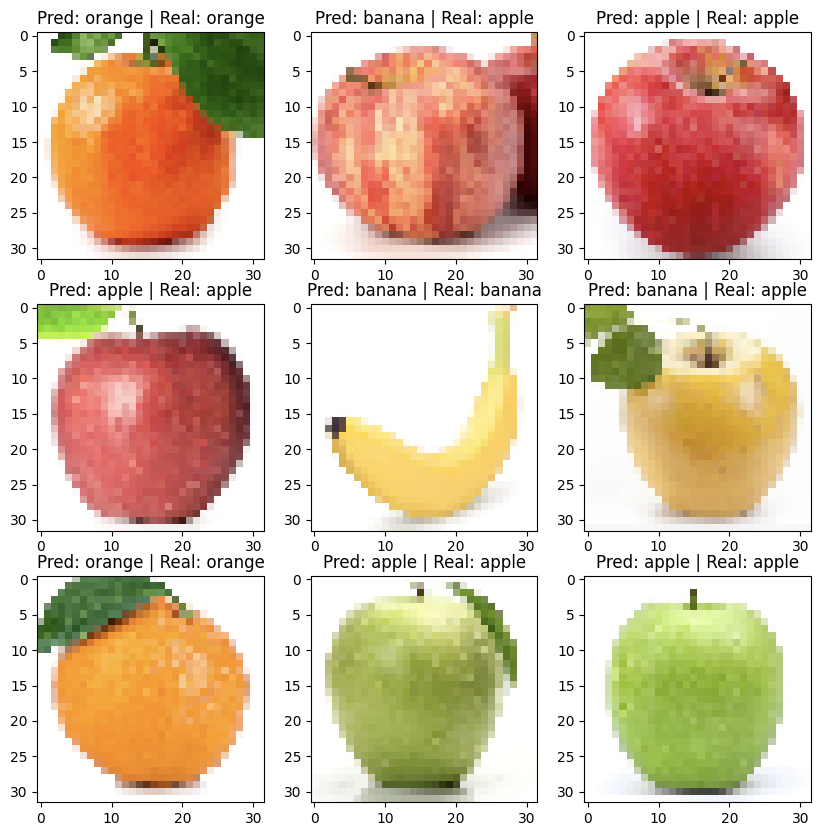

In [12]:
import numpy

plt.figure(figsize=(10,10))
for images, labels in test_ds.take(1):
  classifications = model(images)

  for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    index = numpy.argmax(classifications[i])
    plt.title("Pred: " + class_names[index] + " | Real: " + class_names[labels[i]])

In [13]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

with open("model.tflite", 'wb') as f:
  f.write(tflite_model)

Saved artifact at '/tmp/tmp09813vl4'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 32, 32, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  134168377407632: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134168377408400: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134168377406864: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134168352639504: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134168352639120: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134168352640080: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134168352638928: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134168352641040: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134168352640464: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134168352642000: TensorSpec(shape=(), dtype=tf.resource, name=None)
